Import Libraries

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


Loading the dataset

In [ ]:
file_path = '/content/fake_internship_detection_dataset(1).csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 33)


Displaying the first and last 10 rows, and column names

In [ ]:
print("First 10 rows:")
display(df.head(10))

print("Last 10 rows:")
display(df.tail(10))

print("\nColumn names:")
print(df.columns.tolist())

First 10 rows:


,posting_date,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,...,recruiter_experience_years,recruiter_email_type,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
0,2026-12-31,Frontend Developer,Contract,Onsite,Software,San Francisco,Brown Ltd,Medium,38.0,1,...,0.6,Corporate,0,23.9,1,23,13,61.7,17.1,0
1,2026-12-31,Data Science Intern,Part-Time,Hybrid,EdTech,San Francisco,Alvarez-Burton,Small,11.0,1,...,7.8,Corporate,0,15.9,1,40,24,66.4,34.6,0
2,2026-12-31,Frontend Developer,Contract,Remote,Healthcare,Toronto,Willis PLC,Small,15.0,1,...,4.6,Corporate,0,7.2,1,29,42,49.9,38.1,0
3,2026-12-31,Backend Developer,Full-Time,Hybrid,AI,New York,Johnson LLC,Startup,27.0,1,...,9.2,Corporate,0,15.1,1,0,28,67.5,44.6,0
4,2026-12-31,Frontend Developer,Contract,Remote,Gaming,Toronto,"Anderson, Gibson and Sanchez",Small,37.0,1,...,9.6,Corporate,0,13.3,1,40,36,55.1,32.4,0
5,2026-12-31,ML Engineer,Part-Time,Onsite,Software,Bangalore,Compton and Sons,Small,18.0,0,...,0.0,Corporate,0,11.4,1,34,28,22.3,54.0,1
6,2026-12-31,Cybersecurity Analyst,Full-Time,Remote,AI,Sydney,Hansen PLC,Small,36.0,1,...,9.8,Corporate,0,19.1,1,32,13,65.2,23.3,0
7,2026-12-31,UI/UX Designer,Contract,Remote,Gaming,Dubai,"Miller, Vincent and Hardy",Small,30.0,1,...,0.7,Corporate,0,1.0,1,24,28,52.4,41.7,0
8,2026-12-31,AI Research Intern,Contract,Remote,EdTech,Toronto,Smith-Rodriguez,Small,6.0,1,...,2.6,Corporate,0,21.7,0,28,9,69.6,50.9,1
9,2026-12-31,AI Research Intern,Contract,Remote,E-Commerce,Bangalore,Davis-Dennis,Medium,11.0,1,...,0.0,Corporate,0,24.0,1,34,11,78.2,21.9,0


Last 10 rows:


,posting_date,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,...,recruiter_experience_years,recruiter_email_type,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
99990,2026-02-06,Frontend Developer,Internship,Hybrid,AI,Dubai,"Sanders, Mitchell and Barrett",Startup,7.0,1,...,6.7,Corporate,0,27.4,0,16,22,39.3,65.3,1
99991,2026-02-06,Backend Developer,Contract,Remote,FinTech,Sydney,"Ryan, Mccann and Mathews",Small,36.0,1,...,9.2,Corporate,0,11.3,1,27,34,NaN,77.5,1
99992,2026-02-06,Data Science Intern,Full-Time,Remote,Software,Toronto,Bennett Group,Small,21.0,1,...,0.0,Free,1,21.4,0,39,20,69.5,18.0,0
99993,2026-02-06,UI/UX Designer,Contract,Remote,E-Commerce,London,Valencia Ltd,Medium,9.0,1,...,2.6,Free,1,15.3,1,66,33,44.4,58.5,1
99994,2026-02-06,Frontend Developer,Internship,Remote,Gaming,New York,Chapman-Anderson,Enterprise,25.0,0,...,10.2,Corporate,0,24.0,0,24,14,60.1,28.5,0
99995,2026-02-06,Cybersecurity Analyst,Internship,Remote,Software,Bangalore,Nichols-Williams,Medium,19.0,1,...,3.5,Corporate,0,4.0,1,11,33,60.0,29.9,0
99996,2026-02-06,Cloud Engineer,Contract,Onsite,E-Commerce,San Francisco,Shaw LLC,Small,37.0,1,...,6.4,Corporate,0,14.9,0,2,6,77.9,6.4,0
99997,2026-02-06,AI Research Intern,Contract,Onsite,EdTech,Berlin,Turner-Lee,Small,30.0,1,...,0.0,Corporate,0,25.6,1,0,30,61.9,27.3,0
99998,2026-02-06,UI/UX Designer,Internship,Remote,Gaming,Dubai,"Black, Wilson and Smith",Startup,17.0,1,...,5.2,Free,1,9.3,1,37,65,43.8,75.4,1
99999,2026-02-06,Backend Developer,Internship,Hybrid,EdTech,Sydney,Rios PLC,Startup,9.0,1,...,8.0,Corporate,0,44.5,1,63,34,29.0,54.8,1



Column names:
['posting_date', 'internship_title', 'employment_type', 'work_mode', 'industry', 'location', 'company_name', 'company_size', 'company_age', 'linkedin_presence', 'website_available', 'domain_age_months', 'verification_status', 'stipend', 'unrealistic_salary_flag', 'payment_required', 'registration_fee', 'job_description_length', 'grammatical_errors', 'vague_description_score', 'urgency_score', 'keyword_spam_score', 'fake_certificate_offer', 'recruiter_experience_years', 'recruiter_email_type', 'suspicious_email_domain', 'recruiter_response_time_hours', 'social_media_presence', 'emotional_manipulation_score', 'phishing_language_score', 'trust_signal_score', 'fraud_score', 'is_fake_posting']


Checking data types

In [ ]:
print(df.dtypes)

posting_date                      object
internship_title                  object
employment_type                   object
work_mode                         object
industry                          object
location                          object
company_name                      object
company_size                      object
company_age                      float64
linkedin_presence                  int64
website_available                  int64
domain_age_months                  int64
verification_status                int64
stipend                          float64
unrealistic_salary_flag            int64
payment_required                   int64
registration_fee                   int64
job_description_length             int64
grammatical_errors                 int64
vague_description_score            int64
urgency_score                      int64
keyword_spam_score                 int64
fake_certificate_offer             int64
recruiter_experience_years       float64
recruiter_email_

Checking missing values

In [ ]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing Percentage': (missing / len(df)) * 100
})

missing_df = missing_df[missing_df['Missing Values'] > 0]

print("Columns containing missing values:")
display(missing_df.sort_values('Missing Values', ascending=False))

Columns containing missing values:


,Missing Values,Missing Percentage
trust_signal_score,998,0.998
stipend,976,0.976
company_age,969,0.969


Checking duplicate values

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


Checking the target value

In [ ]:
print("Target column:", 'is_fake_posting')

print("\nTarget values:")
print(df['is_fake_posting'].value_counts())

print("\nTarget percentages:")
print(df['is_fake_posting'].value_counts(normalize=True) * 100)

Target column: is_fake_posting

Target values:
is_fake_posting
0    77703
1    22297
Name: count, dtype: int64

Target percentages:
is_fake_posting
0    77.703
1    22.297
Name: proportion, dtype: float64


Visualizing target distribution

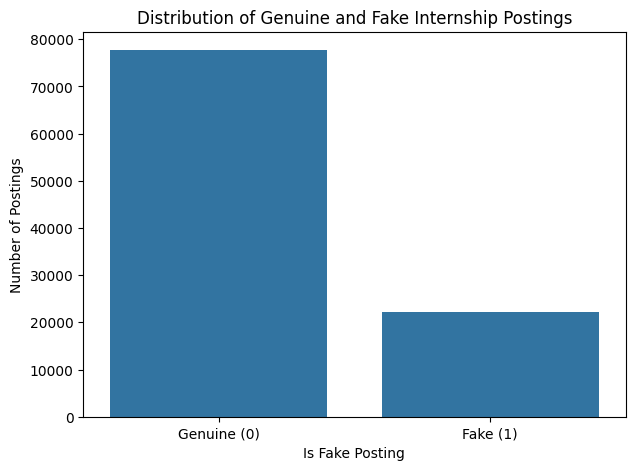

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='is_fake_posting'
)

plt.title('Distribution of Genuine and Fake Internship Postings')
plt.xlabel('Is Fake Posting')
plt.ylabel('Number of Postings')

plt.xticks(
    [0, 1],
    ['Genuine (0)', 'Fake (1)']
)

plt.show()

Checking numerical summary

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
company_age,99031.0,19.953449,11.264648,1.0,10.00,20.0,30.00,39.0
linkedin_presence,100000.0,0.799660,0.400257,0.0,1.00,1.0,1.00,1.0
website_available,100000.0,0.848700,0.358343,0.0,1.00,1.0,1.00,1.0
domain_age_months,100000.0,239.066490,135.870564,1.0,122.00,239.0,356.00,500.0
verification_status,100000.0,0.698870,0.458751,0.0,0.00,1.0,1.00,1.0
stipend,99024.0,35042.968139,14815.200513,2000.0,24864.75,34972.0,44991.25,101917.0
unrealistic_salary_flag,100000.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
payment_required,100000.0,0.099450,0.299267,0.0,0.00,0.0,0.00,1.0
registration_fee,100000.0,249.725010,876.061149,0.0,0.00,0.0,0.00,4999.0
job_description_length,100000.0,1798.925700,599.659539,100.0,1392.00,1799.0,2202.00,4477.0


Separating numerical and categorical columns

In [ ]:
numeric_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['company_age', 'linkedin_presence', 'website_available', 'domain_age_months', 'verification_status', 'stipend', 'unrealistic_salary_flag', 'payment_required', 'registration_fee', 'job_description_length', 'grammatical_errors', 'vague_description_score', 'urgency_score', 'keyword_spam_score', 'fake_certificate_offer', 'recruiter_experience_years', 'suspicious_email_domain', 'recruiter_response_time_hours', 'social_media_presence', 'emotional_manipulation_score', 'phishing_language_score', 'trust_signal_score', 'fraud_score', 'is_fake_posting']

Categorical columns:
['posting_date', 'internship_title', 'employment_type', 'work_mode', 'industry', 'location', 'company_name', 'company_size', 'recruiter_email_type']


Checking possible data leakage

In [ ]:
possible_leakage_features = [
    'fraud_score',
    'trust_signal_score',
    'phishing_language_score'
]

for column in possible_leakage_features:
    if column in df.columns:
        print(f"\n--- {column} ---")
        print(df[column].describe())
        print("\nRelationship with target:")
        print(df.groupby('is_fake_posting')[column].mean())


--- fraud_score ---
count    100000.000000
mean         34.130600
std          21.371174
min           0.000000
25%          18.300000
50%          32.400000
75%          47.800000
max         100.000000
Name: fraud_score, dtype: float64

Relationship with target:
is_fake_posting
0    25.372651
1    64.651249
Name: fraud_score, dtype: float64

--- trust_signal_score ---
count    99002.000000
mean        56.491441
std         16.376778
min          0.000000
25%         45.600000
50%         56.800000
75%         67.800000
max        100.000000
Name: trust_signal_score, dtype: float64

Relationship with target:
is_fake_posting
0    59.877657
1    44.680820
Name: trust_signal_score, dtype: float64

--- phishing_language_score ---
count    100000.000000
mean         20.834940
std          15.873686
min           0.000000
25%           7.000000
50%          20.000000
75%          32.000000
max         100.000000
Name: phishing_language_score, dtype: float64

Relationship with target:
is_fa

Checking unique values of important columns

In [ ]:
columns_to_check = [
    'employment_type',
    'work_mode',
    'industry',
    'company_size',
    'recruiter_email_type',
    'verification_status'
]

for column in columns_to_check:
    print("\n"+f"{column}"+"\n")
    print("Number of unique values:", df[column].nunique())
    print(df[column].value_counts(dropna=False).head(20))


employment_type

Number of unique values: 4
employment_type
Part-Time     25302
Full-Time     25267
Internship    24747
Contract      24684
Name: count, dtype: int64

work_mode

Number of unique values: 3
work_mode
Remote    55044
Hybrid    24764
Onsite    20192
Name: count, dtype: int64

industry

Number of unique values: 9
industry
AI               11188
E-Commerce       11165
Cybersecurity    11127
Healthcare       11123
FinTech          11100
Marketing        11083
EdTech           11077
Gaming           11075
Software         11062
Name: count, dtype: int64

company_size

Number of unique values: 4
company_size
Startup       30032
Small         29916
Medium        24849
Enterprise    15203
Name: count, dtype: int64

recruiter_email_type

Number of unique values: 2
recruiter_email_type
Corporate    74779
Free         25221
Name: count, dtype: int64

verification_status

Number of unique values: 2
verification_status
1    69887
0    30113
Name: count, dtype: int64


Checking high-cardinality features

In [ ]:
high_cardinality_columns = [
    'internship_title',
    'location',
    'company_name'
]

for column in high_cardinality_columns:
    print(
        f"{column}: "
        f"{df[column].nunique(dropna=True):,} unique values"
    )

internship_title: 9 unique values
location: 9 unique values
company_name: 68,503 unique values


Checking numerical ranges

In [ ]:
numeric_features = [
    'company_age',
    'domain_age_months',
    'stipend',
    'registration_fee',
    'job_description_length',
    'grammatical_errors',
    'vague_description_score',
    'urgency_score',
    'keyword_spam_score',
    'recruiter_experience_years',
    'recruiter_response_time_hours',
    'emotional_manipulation_score',
    'phishing_language_score',
    'trust_signal_score',
    'fraud_score'
]

range_summary = df[numeric_features].describe().T

display(
    range_summary[
        ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
    ]
)

,count,mean,std,min,25%,50%,75%,max
company_age,99031.0,19.953449,11.264648,1.0,10.00,20.0,30.00,39.0
domain_age_months,100000.0,239.066490,135.870564,1.0,122.00,239.0,356.00,500.0
stipend,99024.0,35042.968139,14815.200513,2000.0,24864.75,34972.0,44991.25,101917.0
registration_fee,100000.0,249.725010,876.061149,0.0,0.00,0.0,0.00,4999.0
job_description_length,100000.0,1798.925700,599.659539,100.0,1392.00,1799.0,2202.00,4477.0
grammatical_errors,100000.0,2.987400,1.732926,0.0,2.00,3.0,4.00,13.0
vague_description_score,100000.0,30.192450,18.828773,0.0,16.00,30.0,43.00,100.0
urgency_score,100000.0,40.116990,23.531372,0.0,23.00,40.0,56.00,100.0
keyword_spam_score,100000.0,25.554170,18.146699,0.0,11.00,24.0,38.00,100.0
recruiter_experience_years,100000.0,5.064637,2.873265,0.0,3.00,5.0,7.00,17.8


Checking impossible values

In [ ]:
checks = {
    'company_age < 0': (df['company_age'] < 0).sum(),
    'domain_age_months < 0': (df['domain_age_months'] < 0).sum(),
    'stipend < 0': (df['stipend'] < 0).sum(),
    'registration_fee < 0': (df['registration_fee'] < 0).sum(),
    'job_description_length < 0': (df['job_description_length'] < 0).sum(),
    'grammatical_errors < 0': (df['grammatical_errors'] < 0).sum(),
    'recruiter_experience_years < 0': (df['recruiter_experience_years'] < 0).sum(),
    'response_time < 0': (df['recruiter_response_time_hours'] < 0).sum()
}

for check, count in checks.items():
    print(f"{check}: {count}")

company_age < 0: 0
domain_age_months < 0: 0
stipend < 0: 0
registration_fee < 0: 0
job_description_length < 0: 0
grammatical_errors < 0: 0
recruiter_experience_years < 0: 0
response_time < 0: 0


Checking whether scores stay between 0 and 100

In [ ]:
score_columns = [
    'vague_description_score',
    'urgency_score',
    'keyword_spam_score',
    'emotional_manipulation_score',
    'phishing_language_score',
    'trust_signal_score',
    'fraud_score'
]

for column in score_columns:
    below_zero = (df[column] < 0).sum()
    above_100 = (df[column] > 100).sum()

    print(
        f"{column}: "
        f"below 0 = {below_zero}, "
        f"above 100 = {above_100}"
    )

vague_description_score: below 0 = 0, above 100 = 0
urgency_score: below 0 = 0, above 100 = 0
keyword_spam_score: below 0 = 0, above 100 = 0
emotional_manipulation_score: below 0 = 0, above 100 = 0
phishing_language_score: below 0 = 0, above 100 = 0
trust_signal_score: below 0 = 0, above 100 = 0
fraud_score: below 0 = 0, above 100 = 0


Investigating suspicious features

In [ ]:
fraud_features = [
    'fraud_score',
    'trust_signal_score',
    'phishing_language_score'
]

for feature in fraud_features:
    print("\n" + "="*60)
    print(feature)
    print("="*60)

    summary = df.groupby('is_fake_posting')[feature].agg(
        ['count', 'mean', 'median', 'std', 'min', 'max']
    )

    display(summary)


fraud_score


,count,mean,median,std,min,max
is_fake_posting,,,,,,
0,77703,25.372651,26.2,14.191748,0.0,50.0
1,22297,64.651249,61.4,12.152595,50.0,100.0



trust_signal_score


,count,mean,median,std,min,max
is_fake_posting,,,,,,
0,76942,59.877657,60.0,14.986839,0.5,100.0
1,22060,44.680820,44.8,15.516811,0.0,100.0



phishing_language_score


,count,mean,median,std,min,max
is_fake_posting,,,,,,
0,77703,18.440974,17.0,14.784626,0,86
1,22297,29.177692,29.0,16.696342,0,100


Checking correlation between numerical features and target

In [ ]:
correlation = (
    df[numeric_features + ['is_fake_posting']]
    .corr()['is_fake_posting']
    .sort_values(ascending=False)
)

print("Correlation with target:")
display(correlation)

Correlation with target:


,is_fake_posting
is_fake_posting,1.000000
fraud_score,0.765018
registration_fee,0.317199
phishing_language_score,0.281539
vague_description_score,0.243907
urgency_score,0.144182
keyword_spam_score,0.111519
grammatical_errors,0.108857
recruiter_response_time_hours,-0.000325
emotional_manipulation_score,-0.000430


Checking posting date

In [ ]:
print("Data type:", df['posting_date'].dtype)

print("\nFirst 10 dates:")
print(df['posting_date'].head(10))

print("\nNumber of unique dates:")
print(df['posting_date'].nunique())

Data type: object

First 10 dates:
0    2026-12-31
1    2026-12-31
2    2026-12-31
3    2026-12-31
4    2026-12-31
5    2026-12-31
6    2026-12-31
7    2026-12-31
8    2026-12-31
9    2026-12-31
Name: posting_date, dtype: object

Number of unique dates:
329


In [ ]:
date_test = pd.to_datetime(
    df['posting_date'],
    errors='coerce'
)

print("Successfully converted:",
      date_test.notna().sum())

print("Could not convert:",
      date_test.isna().sum())

print("\nDate range:")
print(date_test.min(), "to", date_test.max())

Successfully converted: 100000
Could not convert: 0

Date range:
2026-02-06 00:00:00 to 2026-12-31 00:00:00


In [ ]:
print("DataFrame shape:")
print(df.shape)

print("\nTotal rows:", len(df))

print("\nNon-null values per column:")
display(df.notna().sum().sort_values())

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("\nTarget information:")
print("Target non-null:", df['is_fake_posting'].notna().sum())
print("Target missing:", df['is_fake_posting'].isna().sum())

print("\nDataFrame info:")
df.info()

DataFrame shape:
(100000, 33)

Total rows: 100000

Non-null values per column:


,0
trust_signal_score,99002
stipend,99024
company_age,99031
posting_date,100000
industry,100000
location,100000
employment_type,100000
internship_title,100000
company_size,100000
company_name,100000



Missing values per column:


,0
trust_signal_score,998
stipend,976
company_age,969
posting_date,0
work_mode,0
industry,0
location,0
company_name,0
internship_title,0
company_size,0



Target information:
Target non-null: 100000
Target missing: 0

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   posting_date                   100000 non-null  object 
 1   internship_title               100000 non-null  object 
 2   employment_type                100000 non-null  object 
 3   work_mode                      100000 non-null  object 
 4   industry                       100000 non-null  object 
 5   location                       100000 non-null  object 
 6   company_name                   100000 non-null  object 
 7   company_size                   100000 non-null  object 
 8   company_age                    99031 non-null   float64
 9   linkedin_presence              100000 non-null  int64  
 10  website_available              100000 non-null  int64  
 11  domain_age_m

Check how fraud_score relates to other fraud indicators

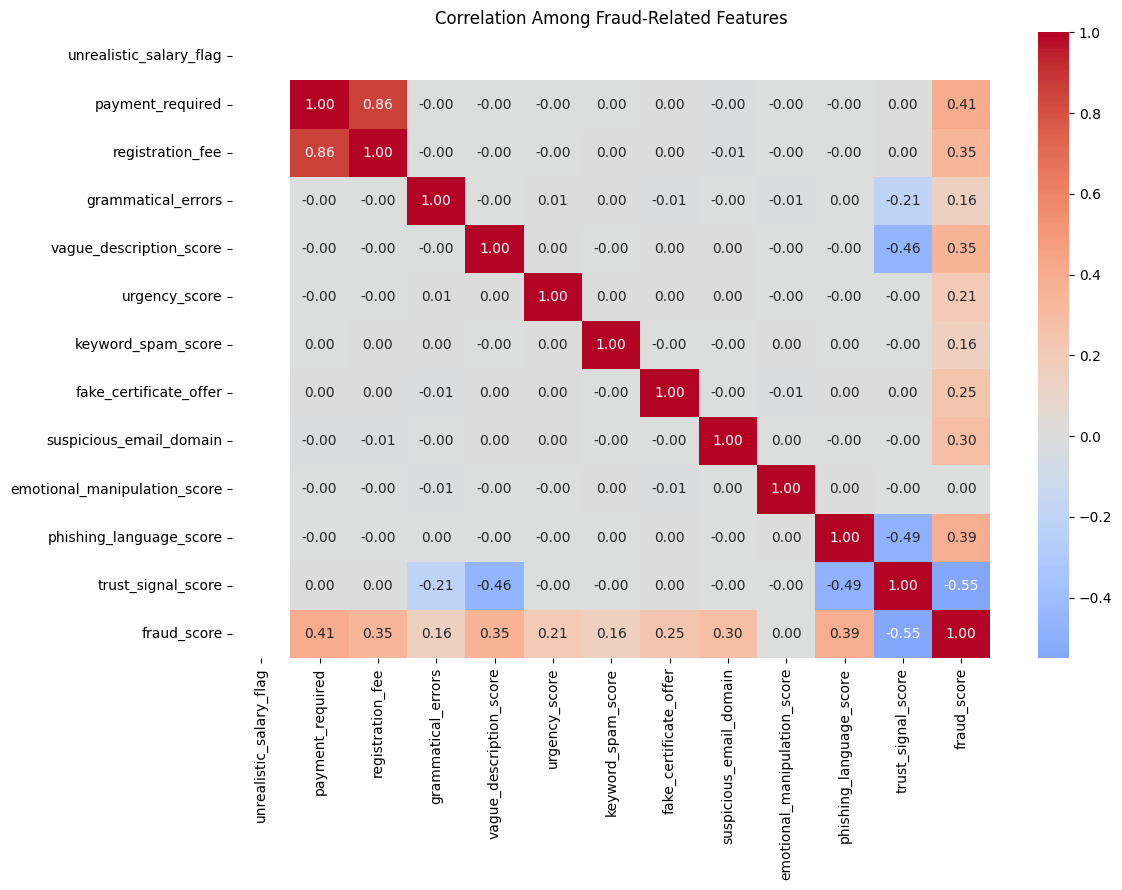

In [ ]:
fraud_related = [
    'unrealistic_salary_flag',
    'payment_required',
    'registration_fee',
    'grammatical_errors',
    'vague_description_score',
    'urgency_score',
    'keyword_spam_score',
    'fake_certificate_offer',
    'suspicious_email_domain',
    'emotional_manipulation_score',
    'phishing_language_score',
    'trust_signal_score',
    'fraud_score'
]

correlation_matrix = df[fraud_related].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Among Fraud-Related Features')
plt.tight_layout()
plt.show()

Check fraud_score against target

In [ ]:
fraud_target = df.groupby('is_fake_posting')['fraud_score'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

display(fraud_target)

,count,mean,median,std,min,max
is_fake_posting,,,,,,
0,77703,25.372651,26.2,14.191748,0.0,50.0
1,22297,64.651249,61.4,12.152595,50.0,100.0


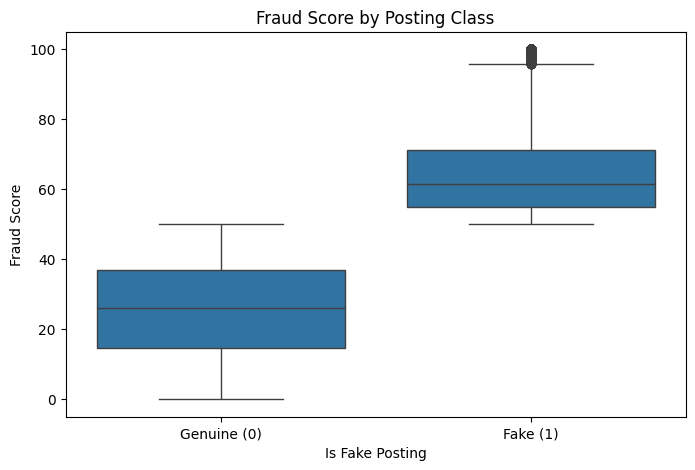

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='is_fake_posting',
    y='fraud_score'
)

plt.title('Fraud Score by Posting Class')
plt.xlabel('Is Fake Posting')
plt.ylabel('Fraud Score')

plt.xticks(
    [0, 1],
    ['Genuine (0)', 'Fake (1)']
)

plt.show()

Check the target missing row

In [ ]:
missing_target = df[df['is_fake_posting'].isna()]

print("Rows with missing target:", len(missing_target))

display(missing_target)

Rows with missing target: 0


,posting_date,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,...,recruiter_experience_years,recruiter_email_type,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting


Remove the unusable target row

In [ ]:
df = df.dropna(subset=['is_fake_posting']).copy()

print("Dataset shape after removing missing target:")
print(df.shape)

print("\nMissing target values:")
print(df['is_fake_posting'].isna().sum())

Dataset shape after removing missing target:
(100000, 33)

Missing target values:
0


Check the cleaned dataset again

In [ ]:
print("Missing values after removing the missing target row:")
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing Percentage': (missing / len(df)) * 100
})

missing_df = missing_df[missing_df['Missing Values'] > 0]

display(missing_df.sort_values('Missing Values', ascending=False))

Missing values after removing the missing target row:


,Missing Values,Missing Percentage
trust_signal_score,998,0.998
stipend,976,0.976
company_age,969,0.969


Inspect feature types before preprocessing

In [ ]:
print("Dataset shape:", df.shape)

print("\n--- Categorical/Object Features ---")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique(dropna=True)} unique values")

print("\n--- Numeric Features with Few Unique Values ---")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if col != 'is_fake_posting' and df[col].nunique(dropna=True) <= 5:
        print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")

Dataset shape: (100000, 33)

--- Categorical/Object Features ---
posting_date: 329 unique values
internship_title: 9 unique values
employment_type: 4 unique values
work_mode: 3 unique values
industry: 9 unique values
location: 9 unique values
company_name: 68503 unique values
company_size: 4 unique values
recruiter_email_type: 2 unique values

--- Numeric Features with Few Unique Values ---
linkedin_presence: [0, 1]
website_available: [0, 1]
verification_status: [0, 1]
unrealistic_salary_flag: [0]
payment_required: [0, 1]
fake_certificate_offer: [0, 1]
suspicious_email_domain: [0, 1]
social_media_presence: [0, 1]


Inspect the date column

In [ ]:
print("Posting date data type:")
print(df['posting_date'].dtype)

print("\nFirst 10 dates:")
print(df['posting_date'].head(10))

print("\nDate range:")
print("Minimum:", df['posting_date'].min())
print("Maximum:", df['posting_date'].max())

Posting date data type:
object

First 10 dates:
0    2026-12-31
1    2026-12-31
2    2026-12-31
3    2026-12-31
4    2026-12-31
5    2026-12-31
6    2026-12-31
7    2026-12-31
8    2026-12-31
9    2026-12-31
Name: posting_date, dtype: object

Date range:
Minimum: 2026-02-06
Maximum: 2026-12-31


Exclude potentially leakage-prone composite feature

In [ ]:
df_model = df.drop(columns=['fraud_score']).copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", df_model.shape)

print("\nFraud score present in modeling data:")
print('fraud_score' in df_model.columns)

Original dataset shape: (100000, 33)
Modeling dataset shape: (100000, 32)

Fraud score present in modeling data:
False


Train/Test

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_model.drop(columns=['is_fake_posting'])
y = df_model['is_fake_posting'].astype(int)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (80000, 31)
Testing set shape: (20000, 31)

Training target distribution:
is_fake_posting
0    62162
1    17838
Name: count, dtype: int64
is_fake_posting
0    77.7025
1    22.2975
Name: proportion, dtype: float64

Testing target distribution:
is_fake_posting
0    15541
1     4459
Name: count, dtype: int64
is_fake_posting
0    77.705
1    22.295
Name: proportion, dtype: float64


Build preprocessing pipeline

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Remove date column from the ordinary categorical list
categorical_features.remove('posting_date')

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Date preprocessing will be handled separately
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nDate feature:")
print(['posting_date'])

Numerical features:
['company_age', 'linkedin_presence', 'website_available', 'domain_age_months', 'verification_status', 'stipend', 'unrealistic_salary_flag', 'payment_required', 'registration_fee', 'job_description_length', 'grammatical_errors', 'vague_description_score', 'urgency_score', 'keyword_spam_score', 'fake_certificate_offer', 'recruiter_experience_years', 'suspicious_email_domain', 'recruiter_response_time_hours', 'social_media_presence', 'emotional_manipulation_score', 'phishing_language_score', 'trust_signal_score']

Categorical features:
['internship_title', 'employment_type', 'work_mode', 'industry', 'location', 'company_name', 'company_size', 'recruiter_email_type']

Date feature:
['posting_date']


Feature Engineering

In [ ]:
def feature_engineering(data):
    data = data.copy()

    # Convert posting_date to datetime
    date = pd.to_datetime(
        data['posting_date'],
        errors='coerce'
    )

    # Extract useful date features
    data['posting_year'] = date.dt.year
    data['posting_month'] = date.dt.month
    data['posting_dayofweek'] = date.dt.dayofweek

    # Remove original date
    data = data.drop(columns=['posting_date'])

    # Remove high-cardinality company name
    data = data.drop(columns=['company_name'])

    return data


# Apply feature engineering separately
X_train_fe = feature_engineering(X_train)
X_test_fe = feature_engineering(X_test)

print("Training shape after feature engineering:",
      X_train_fe.shape)

print("Testing shape after feature engineering:",
      X_test_fe.shape)

print("\nRemaining columns:")
print(X_train_fe.columns.tolist())

Training shape after feature engineering: (80000, 32)
Testing shape after feature engineering: (20000, 32)

Remaining columns:
['internship_title', 'employment_type', 'work_mode', 'industry', 'location', 'company_size', 'company_age', 'linkedin_presence', 'website_available', 'domain_age_months', 'verification_status', 'stipend', 'unrealistic_salary_flag', 'payment_required', 'registration_fee', 'job_description_length', 'grammatical_errors', 'vague_description_score', 'urgency_score', 'keyword_spam_score', 'fake_certificate_offer', 'recruiter_experience_years', 'recruiter_email_type', 'suspicious_email_domain', 'recruiter_response_time_hours', 'social_media_presence', 'emotional_manipulation_score', 'phishing_language_score', 'trust_signal_score', 'posting_year', 'posting_month', 'posting_dayofweek']


Rebuild the preprocessing

In [ ]:
categorical_features = X_train_fe.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_features = X_train_fe.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['company_age', 'linkedin_presence', 'website_available', 'domain_age_months', 'verification_status', 'stipend', 'unrealistic_salary_flag', 'payment_required', 'registration_fee', 'job_description_length', 'grammatical_errors', 'vague_description_score', 'urgency_score', 'keyword_spam_score', 'fake_certificate_offer', 'recruiter_experience_years', 'suspicious_email_domain', 'recruiter_response_time_hours', 'social_media_presence', 'emotional_manipulation_score', 'phishing_language_score', 'trust_signal_score']

Categorical features:
['internship_title', 'employment_type', 'work_mode', 'industry', 'location', 'company_size', 'recruiter_email_type']


In [ ]:
# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Final preprocessing pipeline created successfully!")

Final preprocessing pipeline created successfully!


Baseline Model

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Create baseline model
baseline_model = DummyClassifier(
    strategy='most_frequent'
)

# Train baseline
baseline_model.fit(X_train_fe, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test_fe)

# Calculate metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(
    y_test, y_pred_baseline, zero_division=0
)
baseline_recall = recall_score(
    y_test, y_pred_baseline, zero_division=0
)
baseline_f1 = f1_score(
    y_test, y_pred_baseline, zero_division=0
)

print("=== BASELINE MODEL RESULTS ===")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=['Genuine', 'Fake'],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

=== BASELINE MODEL RESULTS ===
Accuracy : 0.7771
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.78      1.00      0.87     15541
        Fake       0.00      0.00      0.00      4459

    accuracy                           0.78     20000
   macro avg       0.39      0.50      0.44     20000
weighted avg       0.60      0.78      0.68     20000


Confusion Matrix:
[[15541     0]
 [ 4459     0]]


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Create Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train model
logistic_model.fit(X_train_fe, y_train)

# Predictions
y_pred_logistic = logistic_model.predict(X_test_fe)
y_prob_logistic = logistic_model.predict_proba(X_test_fe)[:, 1]

# Metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(
    y_test, y_pred_logistic, zero_division=0
)
logistic_recall = recall_score(
    y_test, y_pred_logistic, zero_division=0
)
logistic_f1 = f1_score(
    y_test, y_pred_logistic, zero_division=0
)
logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)
logistic_pr_auc = average_precision_score(y_test, y_prob_logistic)

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")
print(f"PR-AUC   : {logistic_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['Genuine', 'Fake'],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

=== LOGISTIC REGRESSION RESULTS ===
Accuracy : 0.9176
Precision: 0.8429
Recall   : 0.7751
F1 Score : 0.8076
ROC-AUC  : 0.9681
PR-AUC   : 0.9074

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.94      0.96      0.95     15541
        Fake       0.84      0.78      0.81      4459

    accuracy                           0.92     20000
   macro avg       0.89      0.87      0.88     20000
weighted avg       0.92      0.92      0.92     20000


Confusion Matrix:
[[14897   644]
 [ 1003  3456]]


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree pipeline
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5
    ))
])

# Train model
decision_tree_model.fit(X_train_fe, y_train)

# Predictions
y_pred_tree = decision_tree_model.predict(X_test_fe)
y_prob_tree = decision_tree_model.predict_proba(X_test_fe)[:, 1]

# Metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(
    y_test, y_pred_tree, zero_division=0
)
tree_recall = recall_score(
    y_test, y_pred_tree, zero_division=0
)
tree_f1 = f1_score(
    y_test, y_pred_tree, zero_division=0
)
tree_roc_auc = roc_auc_score(y_test, y_prob_tree)
tree_pr_auc = average_precision_score(y_test, y_prob_tree)

print("=== DECISION TREE RESULTS ===")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_roc_auc:.4f}")
print(f"PR-AUC   : {tree_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=['Genuine', 'Fake'],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

=== DECISION TREE RESULTS ===
Accuracy : 0.8808
Precision: 0.7771
Recall   : 0.6522
F1 Score : 0.7092
ROC-AUC  : 0.9226
PR-AUC   : 0.7872

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.90      0.95      0.92     15541
        Fake       0.78      0.65      0.71      4459

    accuracy                           0.88     20000
   macro avg       0.84      0.80      0.82     20000
weighted avg       0.88      0.88      0.88     20000


Confusion Matrix:
[[14707   834]
 [ 1551  2908]]


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
random_forest_model.fit(X_train_fe, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test_fe)
y_prob_rf = random_forest_model.predict_proba(X_test_fe)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(
    y_test, y_pred_rf, zero_division=0
)
rf_recall = recall_score(
    y_test, y_pred_rf, zero_division=0
)
rf_f1 = f1_score(
    y_test, y_pred_rf, zero_division=0
)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)
rf_pr_auc = average_precision_score(y_test, y_prob_rf)

print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Genuine', 'Fake'],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== RANDOM FOREST RESULTS ===
Accuracy : 0.8923
Precision: 0.8823
Recall   : 0.5965
F1 Score : 0.7118
ROC-AUC  : 0.9539
PR-AUC   : 0.8677

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.89      0.98      0.93     15541
        Fake       0.88      0.60      0.71      4459

    accuracy                           0.89     20000
   macro avg       0.89      0.79      0.82     20000
weighted avg       0.89      0.89      0.88     20000


Confusion Matrix:
[[15186   355]
 [ 1799  2660]]


Cross-Validation & Hyperparameter Tuning

In [ ]:
# ============================================
# LOGISTIC REGRESSION TUNING
# ============================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_params = {
    'classifier__C': [0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

logistic_grid.fit(X_train_fe, y_train)

print("\nBest Logistic Regression parameters:")
print(logistic_grid.best_params_)

print("\nBest Logistic Regression CV F1:")
print(f"{logistic_grid.best_score_:.4f}")



Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Logistic Regression parameters:
{'classifier__C': 1, 'classifier__class_weight': None}

Best Logistic Regression CV F1:
0.8058


In [ ]:
# ============================================
# DECISION TREE TUNING
# ============================================

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

tree_params = {
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': [2, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_params,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

tree_grid.fit(X_train_fe, y_train)

print("\nBest Decision Tree parameters:")
print(tree_grid.best_params_)

print("\nBest Decision Tree CV F1:")
print(f"{tree_grid.best_score_:.4f}")
print("Shape:", df.shape)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Decision Tree parameters:
{'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10}

Best Decision Tree CV F1:
0.7204
Shape: (100000, 33)


In [ ]:
# ============================================
# RANDOM FOREST TUNING
# ============================================

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [8, 12, None],
    'classifier__min_samples_leaf': [2, 5],
    'classifier__class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_fe, y_train)

print("\nBest Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV F1:")
print(f"{rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Random Forest parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}

Best Random Forest CV F1:
0.7821


Final Evaluation

In [ ]:
# Best tuned models
best_logistic = logistic_grid.best_estimator_
best_tree = tree_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predictions
y_pred_logistic_final = best_logistic.predict(X_test_fe)
y_prob_logistic_final = best_logistic.predict_proba(X_test_fe)[:, 1]

y_pred_tree_final = best_tree.predict(X_test_fe)
y_prob_tree_final = best_tree.predict_proba(X_test_fe)[:, 1]

y_pred_rf_final = best_rf.predict(X_test_fe)
y_prob_rf_final = best_rf.predict_proba(X_test_fe)[:, 1]


# Function to calculate metrics
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(
            y_true, y_pred, zero_division=0
        ),
        'Recall': recall_score(
            y_true, y_pred, zero_division=0
        ),
        'F1 Score': f1_score(
            y_true, y_pred, zero_division=0
        ),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob)
    }


logistic_results = evaluate_model(
    'Logistic Regression',
    y_test,
    y_pred_logistic_final,
    y_prob_logistic_final
)

tree_results = evaluate_model(
    'Decision Tree',
    y_test,
    y_pred_tree_final,
    y_prob_tree_final
)

rf_results = evaluate_model(
    'Random Forest',
    y_test,
    y_pred_rf_final,
    y_prob_rf_final
)

final_results = pd.DataFrame([
    logistic_results,
    tree_results,
    rf_results
])

display(final_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9176,0.8429,0.7751,0.8076,0.9681,0.9074
1,Decision Tree,0.8803,0.7744,0.6535,0.7088,0.9269,0.7939
2,Random Forest,0.9005,0.7562,0.8172,0.7855,0.9575,0.8735


Detailed Classification Reports

In [ ]:
print("===== LOGISTIC REGRESSION =====")
print(classification_report(
    y_test,
    y_pred_logistic_final,
    target_names=['Genuine', 'Fake'],
    zero_division=0
))

print("\n===== DECISION TREE =====")
print(classification_report(
    y_test,
    y_pred_tree_final,
    target_names=['Genuine', 'Fake'],
    zero_division=0
))

print("\n===== RANDOM FOREST =====")
print(classification_report(
    y_test,
    y_pred_rf_final,
    target_names=['Genuine', 'Fake'],
    zero_division=0
))

===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

     Genuine       0.94      0.96      0.95     15541
        Fake       0.84      0.78      0.81      4459

    accuracy                           0.92     20000
   macro avg       0.89      0.87      0.88     20000
weighted avg       0.92      0.92      0.92     20000


===== DECISION TREE =====
              precision    recall  f1-score   support

     Genuine       0.90      0.95      0.92     15541
        Fake       0.77      0.65      0.71      4459

    accuracy                           0.88     20000
   macro avg       0.84      0.80      0.82     20000
weighted avg       0.88      0.88      0.88     20000


===== RANDOM FOREST =====
              precision    recall  f1-score   support

     Genuine       0.95      0.92      0.94     15541
        Fake       0.76      0.82      0.79      4459

    accuracy                           0.90     20000
   macro avg       0.85      0.87      0.8

Confusion Matrices


Logistic Regression
[[14897   644]
 [ 1003  3456]]


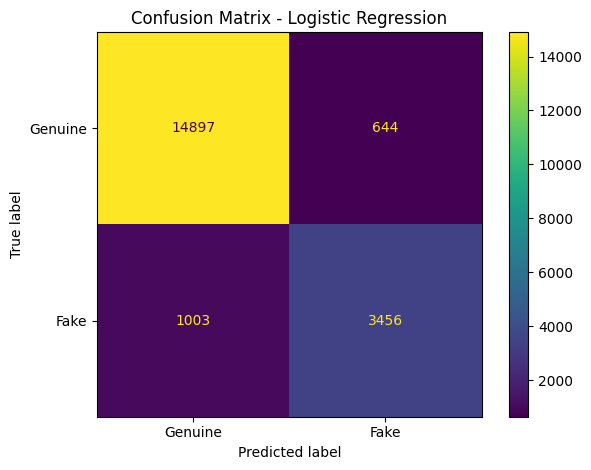


Decision Tree
[[14692   849]
 [ 1545  2914]]


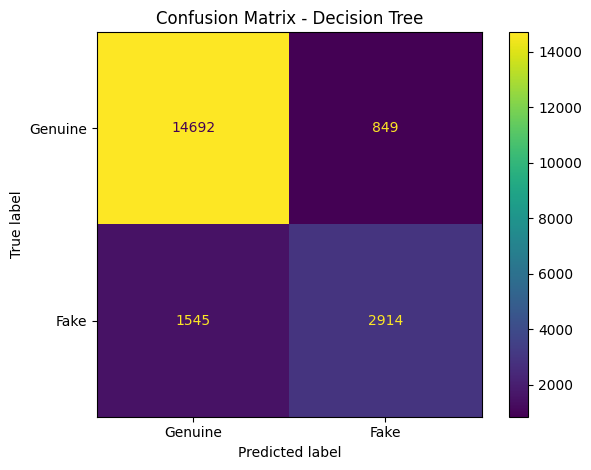


Random Forest
[[14366  1175]
 [  815  3644]]


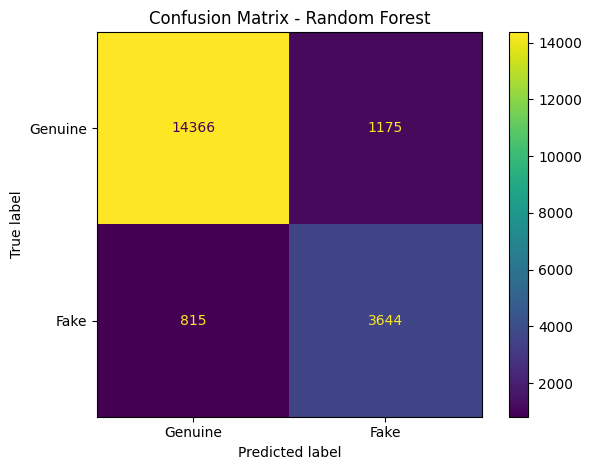

In [ ]:
models_predictions = {
    'Logistic Regression': y_pred_logistic_final,
    'Decision Tree': y_pred_tree_final,
    'Random Forest': y_pred_rf_final
}

for name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Genuine', 'Fake']
    )

    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

ROC Curve Comparison

<Figure size 800x600 with 0 Axes>

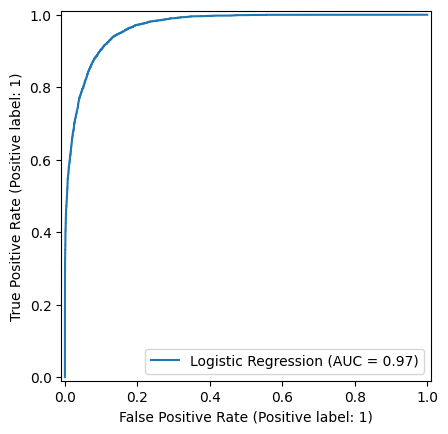

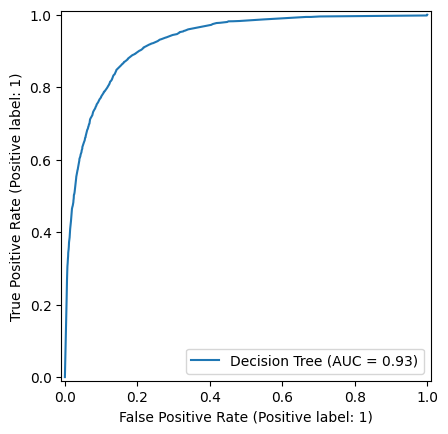

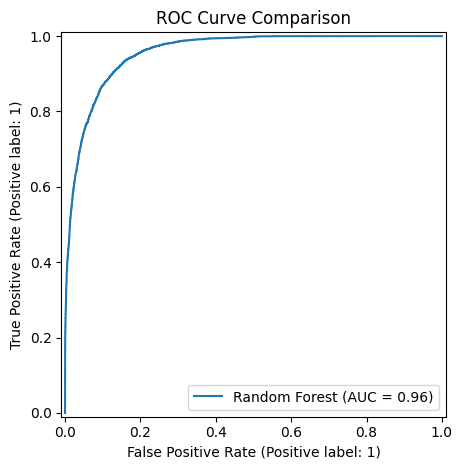

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic_final,
    name='Logistic Regression'
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tree_final,
    name='Decision Tree'
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_final,
    name='Random Forest'
)

plt.title('ROC Curve Comparison')
plt.tight_layout()
plt.show()

Precision-Recall Curve

<Figure size 800x600 with 0 Axes>

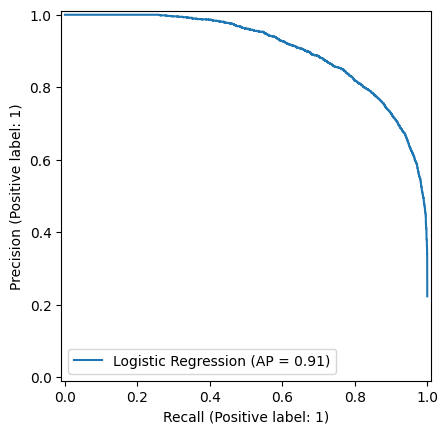

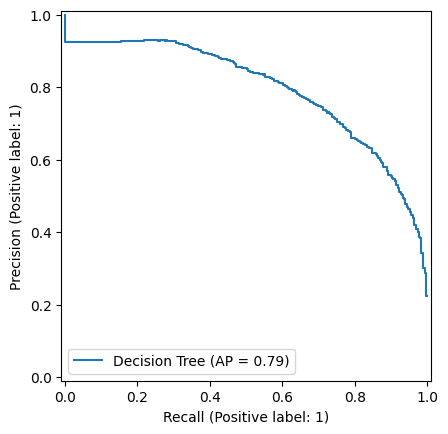

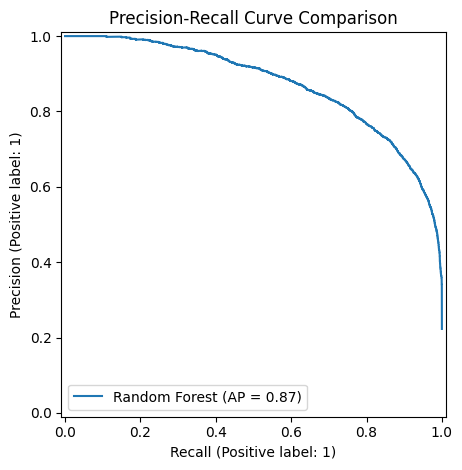

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_logistic_final,
    name='Logistic Regression'
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_tree_final,
    name='Decision Tree'
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf_final,
    name='Random Forest'
)

plt.title('Precision-Recall Curve Comparison')
plt.tight_layout()
plt.show()

Model Comparison

In [ ]:
baseline_row = {
    'Model': 'Baseline',
    'Accuracy': baseline_accuracy,
    'Precision': baseline_precision,
    'Recall': baseline_recall,
    'F1 Score': baseline_f1,
    'ROC-AUC': np.nan,
    'PR-AUC': np.nan
}

comparison_df = pd.DataFrame([
    baseline_row,
    logistic_results,
    tree_results,
    rf_results
])

comparison_df = comparison_df.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9176,0.8429,0.7751,0.8076,0.9681,0.9074
1,Random Forest,0.9005,0.7562,0.8172,0.7855,0.9575,0.8735
2,Decision Tree,0.8803,0.7744,0.6535,0.7088,0.9269,0.7939
3,Baseline,0.7770,0.0000,0.0000,0.0000,NaN,NaN


Select the Best Model

In [ ]:
model_objects = {
    'Logistic Regression': best_logistic,
    'Decision Tree': best_tree,
    'Random Forest': best_rf
}

model_predictions = {
    'Logistic Regression': y_pred_logistic_final,
    'Decision Tree': y_pred_tree_final,
    'Random Forest': y_pred_rf_final
}

best_model_name = final_results.loc[
    final_results['F1 Score'].idxmax(),
    'Model'
]

best_model = model_objects[best_model_name]
best_predictions = model_predictions[best_model_name]

print("Best model based on test F1-score:")
print(best_model_name)

Best model based on test F1-score:
Logistic Regression


Error Analysis

In [ ]:
error_analysis = X_test_fe.copy()

error_analysis['actual'] = y_test.values
error_analysis['predicted'] = best_predictions

# Identify errors
errors = error_analysis[
    error_analysis['actual'] != error_analysis['predicted']
].copy()

false_positives = error_analysis[
    (error_analysis['actual'] == 0) &
    (error_analysis['predicted'] == 1)
].copy()

false_negatives = error_analysis[
    (error_analysis['actual'] == 1) &
    (error_analysis['predicted'] == 0)
].copy()

print("Total test samples:", len(error_analysis))
print("Total errors:", len(errors))
print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

Total test samples: 20000
Total errors: 1647
False positives: 644
False negatives: 1003


Inspect False Positives and False Negatives

In [ ]:
print("===== FALSE POSITIVES =====")
print("Genuine postings incorrectly classified as fake:")
display(false_positives.head(10))

print("\n===== FALSE NEGATIVES =====")
print("Fake postings incorrectly classified as genuine:")
display(false_negatives.head(10))

===== FALSE POSITIVES =====
Genuine postings incorrectly classified as fake:


,internship_title,employment_type,work_mode,industry,location,company_size,company_age,linkedin_presence,website_available,domain_age_months,...,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,posting_year,posting_month,posting_dayofweek,actual,predicted
69491,Frontend Developer,Internship,Hybrid,EdTech,Toronto,Medium,29.0,1,0,359,...,15.6,1,33,31,47.3,2026,5,6,0,1
4105,AI Research Intern,Part-Time,Remote,AI,New York,Startup,35.0,1,0,432,...,19.3,1,55,28,42.4,2026,12,4,0,1
64204,ML Engineer,Full-Time,Remote,EdTech,Berlin,Enterprise,37.0,1,1,456,...,17.8,1,0,13,50.3,2026,6,3,0,1
53436,Cybersecurity Analyst,Contract,Hybrid,Software,Toronto,Small,2.0,1,1,31,...,20.8,1,19,45,32.7,2026,7,3,0,1
81678,AI Research Intern,Contract,Remote,Gaming,Bangalore,Startup,17.0,1,1,200,...,19.7,1,10,50,51.2,2026,4,1,0,1
71709,Cloud Engineer,Part-Time,Remote,Healthcare,Berlin,Startup,28.0,0,0,337,...,37.0,1,54,16,46.4,2026,5,6,0,1
84987,UI/UX Designer,Part-Time,Remote,Gaming,Dubai,Enterprise,13.0,1,1,147,...,18.9,1,0,31,51.9,2026,3,4,0,1
58451,AI Research Intern,Internship,Remote,E-Commerce,Sydney,Small,11.0,1,1,148,...,22.8,0,57,0,65.7,2026,6,1,0,1
84984,Backend Developer,Full-Time,Hybrid,Software,London,Startup,6.0,0,1,76,...,21.7,1,62,39,12.4,2026,3,4,0,1
43135,Data Science Intern,Full-Time,Hybrid,E-Commerce,San Francisco,Startup,12.0,1,0,182,...,22.0,0,58,31,48.4,2026,8,2,0,1



===== FALSE NEGATIVES =====
Fake postings incorrectly classified as genuine:


,internship_title,employment_type,work_mode,industry,location,company_size,company_age,linkedin_presence,website_available,domain_age_months,...,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,posting_year,posting_month,posting_dayofweek,actual,predicted
59768,Frontend Developer,Internship,Hybrid,EdTech,Dubai,Startup,4.0,1,1,42,...,11.1,1,0,38,62.2,2026,6,4,1,0
38504,Data Science Intern,Part-Time,Remote,Marketing,Dubai,Enterprise,38.0,1,1,461,...,26.2,1,35,54,56.7,2026,8,4,1,0
94932,Marketing Intern,Full-Time,Remote,Gaming,Bangalore,Enterprise,25.0,1,0,289,...,27.5,1,39,17,75.3,2026,2,0,1,0
57703,AI Research Intern,Part-Time,Remote,Marketing,Bangalore,Small,12.0,1,1,143,...,28.4,0,42,40,43.0,2026,6,3,1,0
30153,UI/UX Designer,Internship,Remote,E-Commerce,London,Medium,10.0,1,0,142,...,19.1,1,56,44,42.8,2026,9,3,1,0
35040,UI/UX Designer,Internship,Remote,AI,New York,Startup,13.0,0,0,120,...,34.3,1,21,11,41.8,2026,9,1,1,0
31386,Marketing Intern,Contract,Remote,Gaming,New York,Small,6.0,1,0,72,...,34.0,1,62,16,55.6,2026,9,6,1,0
37247,Data Science Intern,Internship,Remote,Gaming,New York,Medium,17.0,0,1,211,...,8.4,0,34,18,35.7,2026,9,1,1,0
39003,Cybersecurity Analyst,Contract,Remote,FinTech,Dubai,Startup,12.0,1,1,136,...,20.3,1,0,51,70.4,2026,8,2,1,0
48529,AI Research Intern,Part-Time,Onsite,AI,Berlin,Enterprise,35.0,1,1,407,...,10.2,1,37,35,59.6,2026,7,5,1,0


Feature Importance

In [ ]:
# Get fitted preprocessing step
rf_preprocessor = best_rf.named_steps['preprocessor']

# Get fitted Random Forest
rf_classifier = best_rf.named_steps['classifier']

# Get feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

# Get importance values
importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance_df.head(20))

,Feature,Importance
21,num__trust_signal_score,0.177378
8,num__registration_fee,0.090011
7,num__payment_required,0.089008
20,num__phishing_language_score,0.085047
11,num__vague_description_score,0.066500
14,num__fake_certificate_offer,0.051350
2,num__website_available,0.047255
12,num__urgency_score,0.045107
1,num__linkedin_presence,0.039320
13,num__keyword_spam_score,0.031830


Plot Top Feature Importance

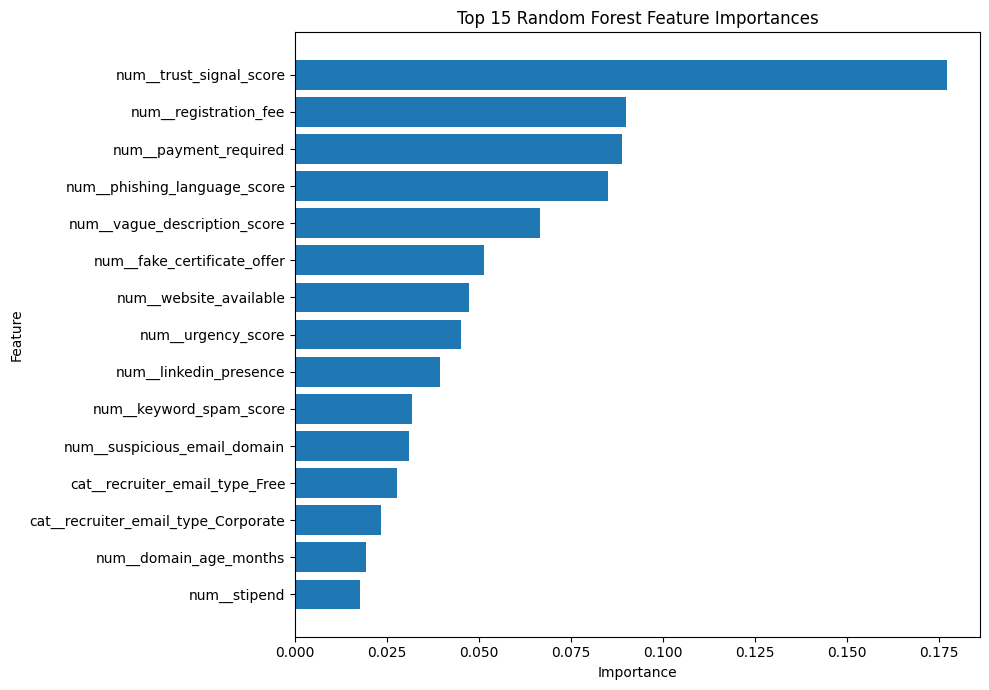

In [ ]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Logistic Regression Coefficients

In [ ]:
logistic_preprocessor = best_logistic.named_steps['preprocessor']
logistic_classifier = best_logistic.named_steps['classifier']

logistic_feature_names = (
    logistic_preprocessor.get_feature_names_out()
)

logistic_coefficients = (
    logistic_classifier.coef_[0]
)

coefficient_df = pd.DataFrame({
    'Feature': logistic_feature_names,
    'Coefficient': logistic_coefficients
})

coefficient_df['Absolute_Coefficient'] = (
    coefficient_df['Coefficient'].abs()
)

coefficient_df = coefficient_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

display(coefficient_df.head(20))

,Feature,Coefficient,Absolute_Coefficient
7,num__payment_required,1.920326,1.920326
20,num__phishing_language_score,1.381440,1.381440
60,cat__recruiter_email_type_Corporate,-1.269492,1.269492
11,num__vague_description_score,1.222252,1.222252
14,num__fake_certificate_offer,1.168364,1.168364
2,num__website_available,-1.140380,1.140380
1,num__linkedin_presence,-1.019960,1.019960
12,num__urgency_score,0.998255,0.998255
21,num__trust_signal_score,-0.997451,0.997451
16,num__suspicious_email_domain,0.801601,0.801601


Positive and Negative Logistic Features

In [ ]:
print("===== FEATURES ASSOCIATED WITH FAKE CLASS =====")

positive_features = coefficient_df[
    coefficient_df['Coefficient'] > 0
].sort_values(
    by='Coefficient',
    ascending=False
)

display(positive_features.head(10))


print("\n===== FEATURES ASSOCIATED WITH GENUINE CLASS =====")

negative_features = coefficient_df[
    coefficient_df['Coefficient'] < 0
].sort_values(
    by='Coefficient',
    ascending=True
)

display(negative_features.head(10))

===== FEATURES ASSOCIATED WITH FAKE CLASS =====


,Feature,Coefficient,Absolute_Coefficient
7,num__payment_required,1.920326,1.920326
20,num__phishing_language_score,1.381440,1.381440
11,num__vague_description_score,1.222252,1.222252
14,num__fake_certificate_offer,1.168364,1.168364
12,num__urgency_score,0.998255,0.998255
16,num__suspicious_email_domain,0.801601,0.801601
13,num__keyword_spam_score,0.773356,0.773356
10,num__grammatical_errors,0.550740,0.550740
37,cat__work_mode_Remote,0.142434,0.142434
61,cat__recruiter_email_type_Free,0.037919,0.037919



===== FEATURES ASSOCIATED WITH GENUINE CLASS =====


,Feature,Coefficient,Absolute_Coefficient
60,cat__recruiter_email_type_Corporate,-1.269492,1.269492
2,num__website_available,-1.140380,1.140380
1,num__linkedin_presence,-1.019960,1.019960
21,num__trust_signal_score,-0.997451,0.997451
36,cat__work_mode_Onsite,-0.696911,0.696911
35,cat__work_mode_Hybrid,-0.677096,0.677096
31,cat__employment_type_Contract,-0.330187,0.330187
57,cat__company_size_Medium,-0.327718,0.327718
58,cat__company_size_Small,-0.309834,0.309834
34,cat__employment_type_Part-Time,-0.307276,0.307276


Cross-Validation Results Summary

In [ ]:
cv_results_summary = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Best CV F1': [
        logistic_grid.best_score_,
        tree_grid.best_score_,
        rf_grid.best_score_
    ]
})

display(cv_results_summary.round(4))

,Model,Best CV F1
0,Logistic Regression,0.8058
1,Decision Tree,0.7204
2,Random Forest,0.7821


Compare CV and Final Test F1

In [ ]:
cv_test_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'CV F1': [
        logistic_grid.best_score_,
        tree_grid.best_score_,
        rf_grid.best_score_
    ],
    'Test F1': [
        logistic_results['F1 Score'],
        tree_results['F1 Score'],
        rf_results['F1 Score']
    ]
})

cv_test_comparison['Difference'] = (
    cv_test_comparison['CV F1'] -
    cv_test_comparison['Test F1']
)

display(cv_test_comparison.round(4))

,Model,CV F1,Test F1,Difference
0,Logistic Regression,0.8058,0.8076,-0.0018
1,Decision Tree,0.7204,0.7088,0.0116
2,Random Forest,0.7821,0.7855,-0.0034


Final Results Table for Report

In [ ]:
final_report_results = comparison_df.copy()

final_report_results = final_report_results[
    [
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC',
        'PR-AUC'
    ]
]

display(final_report_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9176,0.8429,0.7751,0.8076,0.9681,0.9074
1,Random Forest,0.9005,0.7562,0.8172,0.7855,0.9575,0.8735
2,Decision Tree,0.8803,0.7744,0.6535,0.7088,0.9269,0.7939
3,Baseline,0.7770,0.0000,0.0000,0.0000,NaN,NaN


Save Results

In [ ]:
final_report_results.to_csv(
    '/content/model_comparison_results.csv',
    index=False
)

cv_test_comparison.to_csv(
    '/content/cv_vs_test_results.csv',
    index=False
)

feature_importance_df.to_csv(
    '/content/random_forest_feature_importance.csv',
    index=False
)

coefficient_df.to_csv(
    '/content/logistic_regression_coefficients.csv',
    index=False
)

print("Results saved successfully!")

Results saved successfully!


Reproducibility Information

In [ ]:
import sys
import sklearn
import numpy
import pandas

print("Python version:")
print(sys.version)

print("\nPandas version:")
print(pandas.__version__)

print("\nNumPy version:")
print(numpy.__version__)

print("\nScikit-learn version:")
print(sklearn.__version__)

print("\nRandom state used:")
print(RANDOM_STATE)

Python version:
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

Pandas version:
2.2.3

NumPy version:
2.1.3

Scikit-learn version:
1.6.1

Random state used:
42


Final Dataset / Model Summary

In [ ]:
print("============================================")
print("FAKE INTERNSHIP JOB POSTING DETECTION")
print("FINAL PROJECT SUMMARY")
print("============================================")

print("\nDataset:")
print(f"Total labeled samples: {len(df_model)}")

print("\nTrain/Test:")
print(f"Training samples: {len(X_train_fe)}")
print(f"Testing samples: {len(X_test_fe)}")

print("\nFeatures:")
print(f"Features before feature engineering: {X_train.shape[1]}")
print(f"Features after feature engineering: {X_train_fe.shape[1]}")

print("\nExcluded feature:")
print("fraud_score")

print("\nModels:")
print("1. Dummy Baseline")
print("2. Logistic Regression")
print("3. Decision Tree")
print("4. Random Forest")

print("\nBest model:")
print(best_model_name)

print("\nFinal test performance:")
best_row = final_results[
    final_results['Model'] == best_model_name
].iloc[0]

print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1 Score : {best_row['F1 Score']:.4f}")
print(f"ROC-AUC  : {best_row['ROC-AUC']:.4f}")
print(f"PR-AUC   : {best_row['PR-AUC']:.4f}")

FAKE INTERNSHIP JOB POSTING DETECTION
FINAL PROJECT SUMMARY

Dataset:
Total labeled samples: 100000

Train/Test:
Training samples: 80000
Testing samples: 20000

Features:
Features before feature engineering: 31
Features after feature engineering: 32

Excluded feature:
fraud_score

Models:
1. Dummy Baseline
2. Logistic Regression
3. Decision Tree
4. Random Forest

Best model:
Logistic Regression

Final test performance:
Accuracy : 0.9176
Precision: 0.8429
Recall   : 0.7751
F1 Score : 0.8076
ROC-AUC  : 0.9681
PR-AUC   : 0.9074
